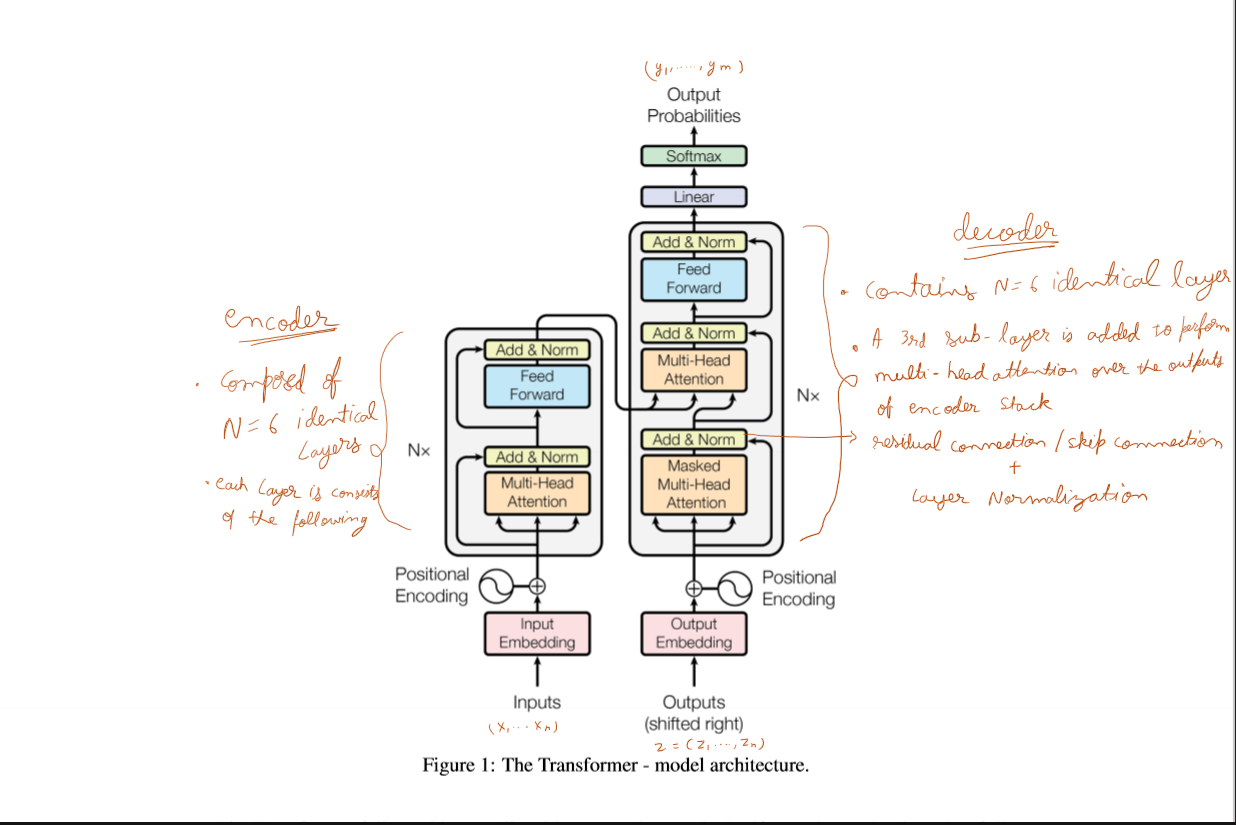

1. How do you train a sequence model in parallel without letting it "cheat" by looking at the answer?
    - Because you are transitioning from sequence models like RNNs, you know that an RNN naturally prevents cheating because it is forced to process data one time-step at a time. It physically cannot see word $t+1$ when predicting word $t$.
    -   Transformers, however, ingest the entire sequence simultaneously to maximize GPU parallelization. While this is perfect for the Encoder, it creates a massive problem for the Decoder during training.

2. To preserve the auto-regressive property (predicting the next word based on previous words) , the authors introduced Masked Multi-Head Attention.
    - When the model calculates the raw attention scores (by multiplying the Query and Key matrices), it generates an $N \times N$ matrix where each word scores its relevance against every other word.
    - To "prevent positions from attending to subsequent positions", we apply a mathematical mask to this matrix before it passes through the Softmax function.We take the upper-triangular part of the matrix (which represents all "future" connections) and set those values to $-\infty$.
    - When the Softmax function is applied, $e^{-\infty}$ evaluates to exactly $0$.
    - This zeros out the attention weights for future tokens. The word "The" will have a $0\%$ attention weight for "black" and "cat". It is effectively blinded to the future.

3. Masking alone isn't enough; the data must be aligned correctly. This is where the "offset by one position" comes in (often labeled as "shifted right" in architecture diagrams).
    - When feeding the target sequence into the Decoder, we prepend a special starting token (like <SOS> for Start of Sequence) and drop the last word.
    - Let's look at the mapping for our target [The, black, cat, <EOS>]:
        - Decoder Input (Shifted Right): [<SOS>, The, black, cat]
        - Decoder Target Output: [The, black, cat, <EOS>]
    - By shifting the inputs right by one, and blinding the model to anything ahead of its current position, the architecture strictly forces the model to predict token $i$ relying only on tokens $0$ through $i-1$.

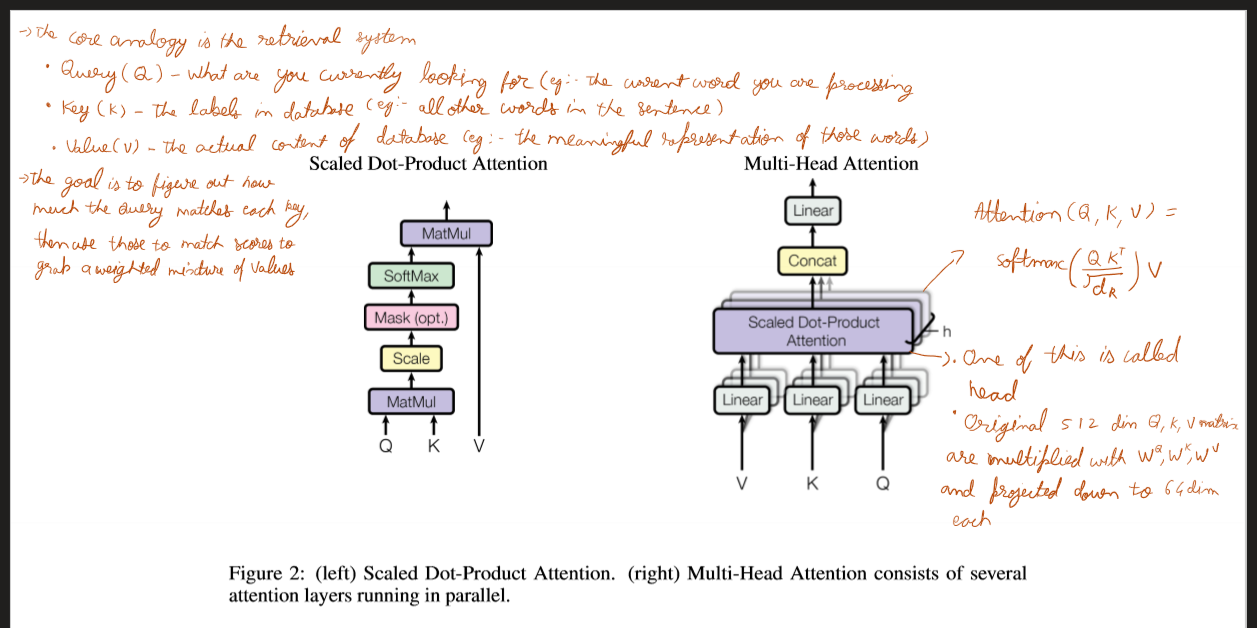

1. Scaled Dot-Product Attention (The Math)

    - Step A: The Dot Product ($QK^{T}$)
        - You take the dot product of the Query matrix with the transposed Key matrix. In linear algebra, a dot product is a measure of similarity. If a Query vector and a Key vector are pointing in the same direction, their dot product is a large positive number. If they are orthogonal, it's near zero.
            - This step creates an $N \times N$ matrix of raw "attention scores," telling you exactly how relevant every word is to every other word.
    
    - Step B: The Scaling Factor ($\frac{1}{\sqrt{d_{k}}}$)
        - This is a critical stabilization trick that directly impacts gradient descent. $d_k$ is the dimensionality of your Key vectors (in the paper, it's 64).
            - If you multiply two vectors of length 64 with random values, the resulting dot product can have a very high variance (it gets mathematically huge).
            - When you feed massive numbers into a Softmax function, it squashes the largest number to essentially 1 and everything else to 0. The probability distribution becomes a sharp one-hot vector.
            - The Problem: When Softmax is pushed into these extreme regions, the gradients become infinitely small. The network stops learning because the error cannot flow backward through the Softmax operation.
            - The Fix: By dividing the raw scores by the square root of the dimension ($\sqrt{64} = 8$), you scale the numbers down, keeping the Softmax output smooth and preserving a healthy gradient landscape.
    - Step C: Softmax
        - The Softmax function converts those scaled raw scores into a probability distribution. All the scores for a given Query will now add up to 1.0 (or 100%). For example, the word "bank" might pay 80% of its attention to "river" and 20% to "water".
    
    - Step D: Multiply by Values ($V$)
        - Finally, you multiply your Softmax probability matrix by the Value matrix. If the Softmax assigned 80% weight to "river", the final output vector for "bank" will consist of 80% of the "river" vector's features. You are outputting a weighted sum of the Values.

2. Multi-Head Attention
    - Instead of one $512$-dimensional attention operation, the paper splits the embedding into $h = 8$ separate, smaller "heads".
        - Project: The original 512-dimensional $Q$, $K$, and $V$ matrices are multiplied by learned weight matrices ($W^Q, W^K, W^V$) to project them down to 64 dimensions each ($d_k = 64$).
        - Parallel Attention: The Scaled Dot-Product Attention is calculated for all 8 heads simultaneously. Because $8 \times 64 = 512$, the computational cost is virtually identical to doing it once in full dimensionality.
        - Specialization: Because the weights are randomly initialized, each head learns to look for different things. Head 1 might become a "pronoun resolution" head (linking "it" to "cat"). Head 2 might become an "adjective-noun" head. Head 3 might focus purely on the position of the words.
        - Concatenate: The $64$-dimensional outputs from all 8 heads are concatenated back into a single $512$-dimensional vector.
        - Final Linear Layer: This combined vector is multiplied by a final weight matrix ($W^O$) to mix the insights from all the different heads together before passing the data to the next layer.

3. Feed-Forward Networks
In addition to attention sub-layers, each of the layers in our encoder and decoder contains a fully
connected feed-forward network, which is applied to each position separately and identically. This
consists of two linear transformations with a ReLU activation in between.
FFN(x) = max(0,$xW_1$ + $b_1$)$W_2$ + $b_2$

4. Positional Encoding
Since our model contains no recurrence and no convolution, in order for the model to make use of the
order of the sequence, we must inject some information about the relative or absolute position of the
tokens in the sequence. To this end, we add "positional encodings" to the input embeddings at the
bottoms of the encoder and decoder stacks. The positional encodings have the same dimension dmodel
as the embeddings, so that the two can be summed.